In [1]:
# Import your existing types and functions
from pathlib import Path

import pandas as pd
import torch
from js_embedding_vis import write_inlined_config
from muutils.collect_warnings import CollateWarnings

from spd.analysis.embed_vis import AnalysisConfig, coactivation_analysis, plot_embedding_label_grid
from spd.analysis.grouping import (
    CoactivationResults,
    get_coactivations,
)
from spd.data_utils import SparseFeatureDataset
from spd.utils import get_device

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE = get_device()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = 'cuda'


In [4]:
coactivations_tms: CoactivationResults = get_coactivations(
    model_path=Path("../data/tms-decomp/model_40000.pth"),
    dataset_cls=SparseFeatureDataset,
    dataset_kwargs=dict(
        value_range=(0.0, 1.0),
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["linear1", "linear2"]],
    ),
    device=DEVICE,
)

In [14]:
# Full analysis


df: pd.DataFrame
with CollateWarnings(fmt="({count}x) {filename}:{lineno}\n  {category}: {message}"):
    df, metadata = coactivation_analysis(
        group=coactivations_tms["group_0"],
        config=AnalysisConfig(
            embedding_configs={
                "isomap": {"n_neighbors": [2, 4, 8, 16, 32, 64, 128]},
                # "umap": {"n_neighbors": [2, 8, 32, 128]},
                # "tsne": {"perplexity": [5, 10, 20, 30, 50]},
            },
            clustering_configs={
                # "kmeans": {"n_clusters": [3, 5, 8, 10, 15, 20]},
                # "agglomerative": {"n_clusters": [3, 5, 8, 10, 15, 20]},
                # "spectral": {"n_clusters": [3, 5, 8, 10, 15, 20]},
                # "dbscan": {"eps": [0.05, 0.1, 0.2, 0.3, 0.5]},
                # "optics": {"min_samples": [3, 5, 10, 20]},
                "kmeans": {"n_clusters": [4]},
                "agglomerative": {"n_clusters": [4]},
                # "spectral": {"n_clusters": [4]},
                # "optics": {"min_samples": [4]},
            },
            n_components=3,
        ),
    )

# Print structure
print(metadata.describe())

Starting coactivation analysis...
Computing hierarchical clustering...
Working with 113 alive features out of 400 total
Computing isomap embeddings...
Computing clustering on embeddings...
Analysis complete! DataFrame shape: (78, 35)
Column groups: ['feat(4)', 'embed(18)', 'feat.class(13)']
Analysis df with 400 features (113 alive)

Column Groups:
  feat: 4 columns
    ['feat.alive', 'feat.activation_freq', 'feat.activation_freq_log', 'feat.module']
  embed: 18 columns
    ['embed.isomap.n_neighbors-002.ax.0', 'embed.isomap.n_neighbors-002.ax.1', 'embed.isomap.n_neighbors-002.ax.2', 'embed.isomap.n_neighbors-004.ax.0', 'embed.isomap.n_neighbors-004.ax.1'] ... ['embed.isomap.n_neighbors-064.ax.1', 'embed.isomap.n_neighbors-064.ax.2']
  feat.class: 13 columns
    ['feat.class.hclust', 'feat.class.isomap.n_neighbors-002.kmeans.n_clusters-004', 'feat.class.isomap.n_neighbors-002.agglomerative.n_clusters-004', 'feat.class.isomap.n_neighbors-004.kmeans.n_clusters-004', 'feat.class.isomap.n_n

[ /home/miv/projects/MATS/apd/spd/analysis/embedding.py:163 ] jac: μ=0.00 σ=0.04 x̃=0.00 R=[0.00,1.00] ℙ˪=|█▄▃▃▂▂▄| shape=(400,400) dtype=torch.float32 device=cpu ∇✗
[ /home/miv/projects/MATS/apd/spd/analysis/embedding.py:170 ] dist: μ=1.00 σ=0.03 x̃=1.00 R=[0.50,1.00] ℙ˪=|▄▂▃▃▃▅█| shape=(400,400) dtype=torch.float32 device=cpu ∇✗
(1x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384
(18x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/scipy/sparse/_index.py:168
(3x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384


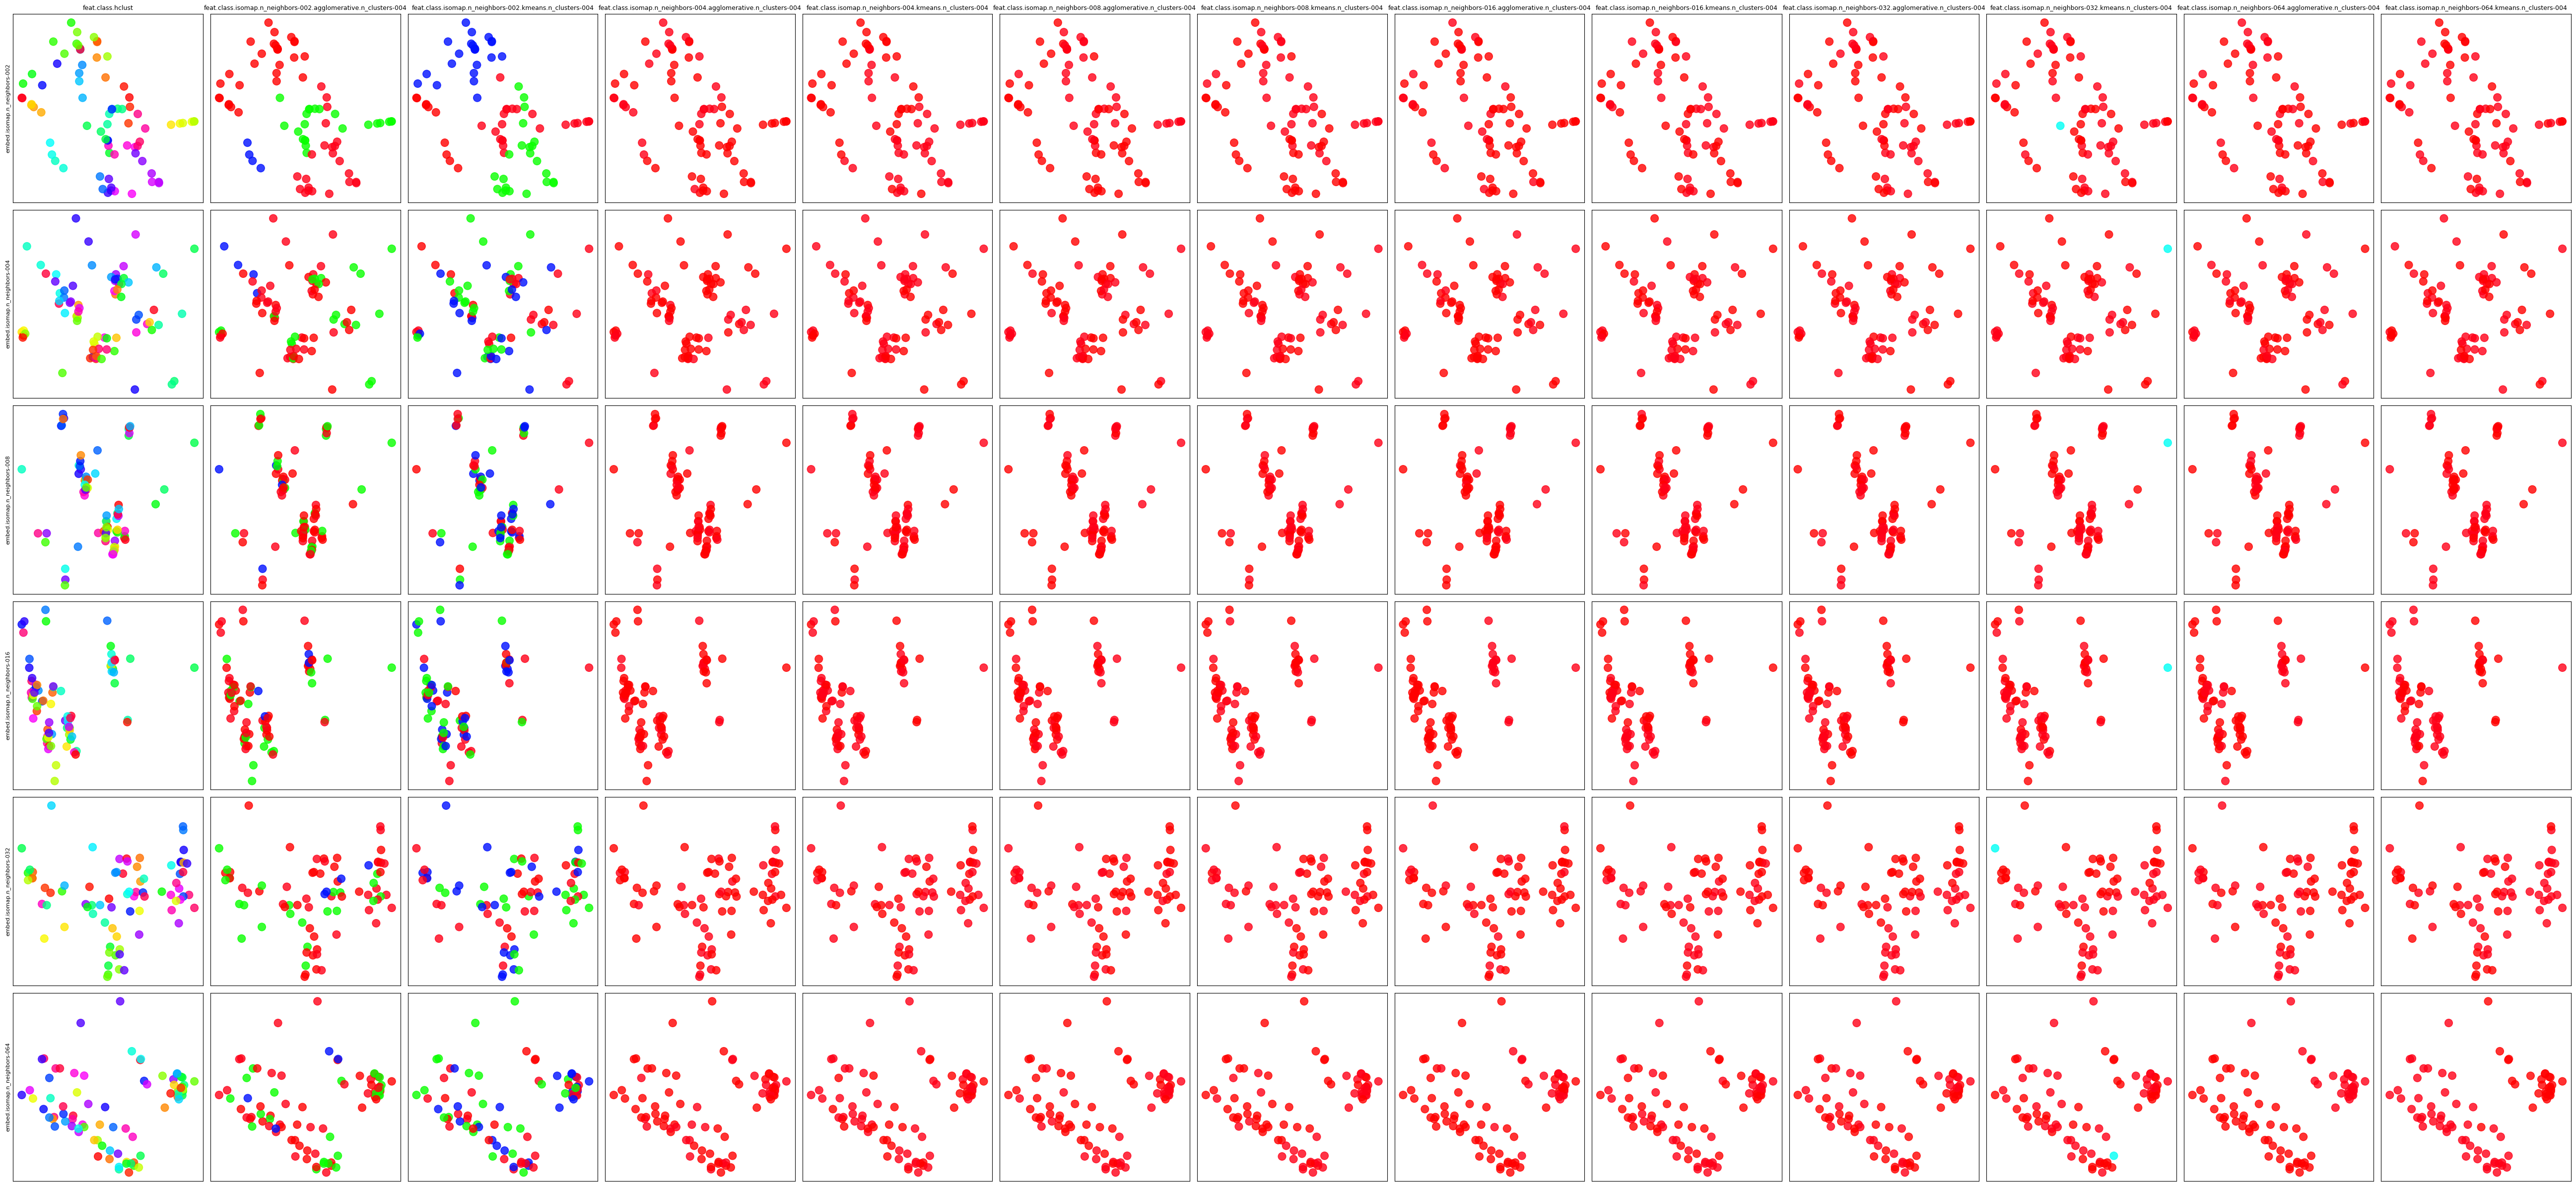

In [15]:
plot_embedding_label_grid(
	df,
	metadata,
	figsize_per_cell=(4,4),
	point_size=128,
)

In [ ]:
df_jsonl = df.to_dict(orient="records")

df.to_json(
	Path("temp.jsonl"),
	orient="records",
	lines=True,
)

write_inlined_config(
    cfg=dict(
        dataFile=None,
        data=df_jsonl,
        numericalPrefix="embed.isomap.n_neighbors-064.ax.",
        defaultColorColumn="feat.class.hclust",
        defaultSelectionColumn="feat.class.hclust",
        hoverColumns=[
            "feat.class.hclust",
            "feat.activation_freq",
        ],
    ),
    out_path=Path("../display/embed_vis.html"),
);